# V4-mini: Precision–Recall 选择性测试

在 **`ACTIVE_CURVES`** 列表中填入想跑的曲线 ID，其余不跑。

可用曲线 ID：
- `0` navigamer_tolerance
- `1` ts_top_k
- `2` strobemer_k
- `3` strobemer_w_min
- `4` spaced_weight


In [1]:
# ══════════════════════════════════════════════
# 在这里选择要跑的曲线（填编号，顺序任意）
# 0=navigamer_tolerance  1=ts_top_k
# 2=strobemer_k          3=strobemer_w_min
# 4=spaced_weight
# ══════════════════════════════════════════════
ACTIVE_CURVES = [0, 1, 2, 3]  # ← 修改这里（排除 spaced_seed=4）


In [2]:
%matplotlib inline
import os
import sys
import random
import tempfile
import subprocess
import csv
import json
import time
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import numpy as np
import edlib

_nb_dir = Path.cwd()
if (_nb_dir / "v4_precision_recall_tradeoff.ipynb").exists():
    METHODS_DIR = _nb_dir
elif (_nb_dir / "methods" / "v4_precision_recall_tradeoff.ipynb").exists():
    METHODS_DIR = _nb_dir / "methods"
else:
    METHODS_DIR = _nb_dir
PROJECT_DIR = METHODS_DIR.parent
NAVIGAMER_CPP = PROJECT_DIR / "navigamer_cpp"
OUTPUT_DIR = METHODS_DIR / "v4_benchmark_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("METHODS_DIR:", METHODS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("NAVIGAMER_CPP:", NAVIGAMER_CPP)

METHODS_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods
OUTPUT_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods/v4_benchmark_output
NAVIGAMER_CPP: /home/luting/projects/AnchorMapping/NavigaMer/navigamer_cpp


In [3]:
# ── Data generation (reused from v3) ──
def load_reference(fasta_path, max_len=10000):
    seq_parts = []
    with open(fasta_path) as f:
        for line in f:
            if line.startswith(">"):
                continue
            seq_parts.append(line.strip().upper())
    return "".join(seq_parts)[:max_len]

def mutate_sequence(sequence, mutation_rate, rng):
    bases = ['A', 'T', 'C', 'G']
    seq_list = list(sequence)
    length = len(seq_list)
    num_mutations = max(1, int(length * mutation_rate))
    for _ in range(num_mutations):
        idx = rng.randint(0, len(seq_list) - 1)
        op = rng.choice(['sub', 'del', 'ins'])
        if op == 'sub':
            original = seq_list[idx]
            choices = [b for b in bases if b != original]
            if choices:
                seq_list[idx] = rng.choice(choices)
        elif op == 'del' and len(seq_list) > length // 2:
            del seq_list[idx]
        elif op == 'ins':
            seq_list.insert(idx, rng.choice(bases))
    return ''.join(seq_list)

def generate_test_data(reference, mutation_rate, num_reads, read_length, seed=42):
    rng = random.Random(seed)
    reads = []
    ref_len = len(reference)
    for i in range(num_reads):
        start = rng.randint(0, max(0, ref_len - read_length))
        fragment = reference[start:start + read_length]
        if len(fragment) < read_length:
            continue
        mutated = mutate_sequence(fragment, mutation_rate, rng)
        reads.append((f"read_{i:04d}", mutated, start, fragment))
    return reads

def _simple_edit_dist(a, b):
    la, lb = len(a), len(b)
    if abs(la - lb) > max(la, lb) // 2:
        return max(la, lb)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a):
        curr = [i + 1] + [0] * lb
        for j, cb in enumerate(b):
            curr[j + 1] = min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (0 if ca == cb else 1))
        prev = curr
    return prev[lb]

def find_true_positions(reference, query_seq, edit_tolerance, window_size=None):
    ws = window_size if window_size is not None else len(query_seq)
    positions = []
    for s in range(len(reference) - ws + 1):
        if _simple_edit_dist(reference[s:s + ws], query_seq) <= edit_tolerance:
            positions.append(s)
    return positions

def _build_true_set_worker(args):
    rid, mutated_seq, reference, edit_tolerance, window_size = args
    return rid, frozenset(find_true_positions(reference, mutated_seq, edit_tolerance, window_size=window_size))

def build_true_sets(reads, reference, edit_tolerance, window_size=None):
    tasks = [(r[0], r[1], reference, edit_tolerance, window_size) for r in reads]
    result = {}
    with ProcessPoolExecutor() as pool:
        for rid, positions in pool.map(_build_true_set_worker, tasks):
            result[rid] = positions
    return result

def write_fasta(path, name, seq):
    with open(path, 'w') as f:
        f.write(f">{name}\n{seq}\n")

def write_fastq(path, reads):
    with open(path, 'w') as f:
        for r in reads:
            f.write(f"@{r[0]}\n{r[1]}\n+\n{'I' * len(r[1])}\n")

In [4]:
# ── Method runners (navigamer, strobemer, spaced_seed, tensor_sketch) ──
def run_navigamer(ref_fa, query_fq, out_tsv, params):
    binary = NAVIGAMER_CPP / "navigamer"
    if not binary.exists():
        return {"error": f"navigamer not found at {binary}", "hits": defaultdict(list), "candidates_count": 0, "runtime": 0}
    window = params.get("window_size", 100)
    stride = params.get("stride", 1)
    tol = params.get("tolerance", 6)
    r_sw = params.get("r_sw", 5)
    r_mw = params.get("r_mw", 15)
    r_lw = params.get("r_lw", 30)
    cmd = [str(binary), "benchmark", "--ref", ref_fa, "--reads", query_fq,
           "--tolerance", str(tol), "--window", str(window), "--stride", str(stride),
           "--r-sw", str(r_sw), "--r-mw", str(r_mw), "--r-lw", str(r_lw),
           "--out", out_tsv]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(NAVIGAMER_CPP))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    return parse_navigamer_output(out_tsv, elapsed)

def parse_navigamer_output(tsv_path, runtime=0.0):
    hits = defaultdict(list)
    if not os.path.exists(tsv_path):
        return {"hits": hits, "candidates_count": 0, "runtime": runtime}
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rid = row.get("query_id") or row.get("read_id", "")
            if not rid:
                continue
            ref_start = row.get("reference_start", "")
            if ref_start.isdigit() and row.get("hit_id"):
                hits[rid].append({
                    "ref_start": int(ref_start),
                    "ref_pos": int(ref_start),
                    "edit_dist": int(row.get("edit_distance") or 0),
                    "score": int(row.get("score") or 0),
                })
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": runtime}

def run_strobemer(ref_fa, query_fq, out_tsv, params):
    strobe_dir = METHODS_DIR / "ksahlin" / "strobemers"
    cmd = [sys.executable, str(strobe_dir / "StrobeMap"), "--queries", query_fq, "--references", ref_fa,
           "--outfolder", str(Path(out_tsv).parent), "--prefix", Path(out_tsv).stem, "--k", str(params.get("k", 15)),
           "--strobe_w_min_offset", str(params.get("w_min", 20)), "--strobe_w_max_offset", str(params.get("w_max", 70)),
           "--w", str(params.get("w", 1)), "--n", str(params.get("order", 2)), "--rev_comp"]
    env = os.environ.copy()
    env["PYTHONPATH"] = str(strobe_dir) + os.pathsep + env.get("PYTHONPATH", "")
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, env=env, cwd=str(strobe_dir))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    raw = Path(out_tsv).parent / (Path(out_tsv).stem + ".tsv")
    hits = parse_strobemer_output(str(raw))
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": elapsed}

def parse_strobemer_output(raw_path):
    results = defaultdict(list)
    if not os.path.exists(raw_path):
        return results
    current_query = None
    with open(raw_path) as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if line.startswith(">"):
                parts = line[2:].strip().split()
                current_query = parts[0] if parts else None
            else:
                fields = line.strip().split()
                if len(fields) >= 4 and current_query:
                    ref_pos = int(fields[1])
                    query_pos = int(fields[2])
                    inferred_start = ref_pos - query_pos
                    results[current_query].append({"ref_pos": inferred_start, "ref_start": inferred_start})
    return results

def run_spaced_seed(ref_fa, query_fq, out_tsv, params):
    ss_dir = METHODS_DIR / "spaced_seed"
    workers = int(params.get("workers", max(1, min(16, (os.cpu_count() or 1) // 2))))
    cmd = [sys.executable, str(ss_dir / "ales_fasta_fastq_align_parallel.py"), "--fasta", ref_fa, "--fastq", query_fq,
           "--output", out_tsv, "--weight", str(params.get("weight", 11)), "--homology-length", str(params.get("homology_length", 64)),
           "--similarity", str(params.get("similarity", 0.8)), "--k-seeds", str(params.get("k_seeds", 1)), "--no-revcomp", "--workers", str(workers)]
    if params.get("upper_bound") is not None:
        cmd += ["--upper-bound", str(params["upper_bound"])]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(ss_dir))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    hits, raw_total = parse_spaced_seed_output(out_tsv)
    return {"hits": hits, "candidates_count": raw_total, "runtime": elapsed}

def parse_spaced_seed_output(tsv_path):
    results = defaultdict(list)
    raw_total = 0
    if not os.path.exists(tsv_path):
        return results, raw_total
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            raw_total += int(row.get("raw_candidate_count", 0) or 0)
            rid = row.get("read_id", "")
            if not rid:
                continue
            # Expand all raw seed match positions (seed_ref_starts column)
            seed_col = row.get("seed_ref_starts", "")
            if seed_col:
                for s in seed_col.split(","):
                    s = s.strip()
                    if s:
                        pos = int(s)
                        results[rid].append({"ref_start": pos, "ref_pos": pos})
            elif rid != "*":
                # Fallback for old-format TSV without seed_ref_starts column
                ref_start = int(row.get("reference_start", 0))
                if ref_start >= 0:
                    results[rid].append({"ref_start": ref_start, "ref_pos": ref_start})
    return results, raw_total

def run_tensor_sketch(ref_fa, query_fq, out_tsv, params):
    binary = METHODS_DIR / "tensor-sketch-alignment" / "metagraph" / "mgsketch_index"
    if not binary.exists():
        return {"error": "mgsketch_index not found", "hits": defaultdict(list), "candidates_count": 0, "runtime": 0}
    cmd = [str(binary), "--ref_fasta", ref_fa, "--query_fastq", query_fq, "--output_tsv", out_tsv,
           "--window_size", str(params.get("window_size", 150)), "--stride", str(params.get("stride", 1)),
           "--hnsw_ef_search", str(params.get("hnsw_ef_search", 50)), "--top_k", str(params.get("top_k", 5)),
           "--sketch_dim", str(params.get("sketch_dim", 128)), "--tuple_size", str(params.get("tuple_size", 3))]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    hits = parse_tensor_sketch_output(out_tsv)
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": elapsed}

def parse_tensor_sketch_output(tsv_path):
    results = defaultdict(list)
    if not os.path.exists(tsv_path):
        return results
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rid = row.get("read_id", "")
            if rid:
                ref_start = int(row.get("reference_start", 0))
                results[rid].append({"ref_start": ref_start, "ref_pos": ref_start})
    return results

In [5]:
# ── Metrics: candidate-position-level PR ──
# 所有方法统一到"候选位置"粒度：
#   seed-and-extend: 每个 seed 命中的 inferred_start = 一个候选位置
#   sketch-based:    top_k / hit 位置 = 候选位置
# 分桶去重（桶宽 = POS_TOLERANCE）后做集合运算，两类算法完全对等可比。
POS_TOLERANCE = 5  # 桶宽：同一桶内的候选视为同一个比对位置

def compute_hit_pr(match_results, reads, precomputed_true_sets,
                   pos_tolerance=POS_TOLERANCE, total_windows_ref=None):
    """候选位置粒度 PR（两类算法统一）:
    - predicted: 所有候选位置按 pos_tolerance 分桶去重后的桶集合
    - actual:    true_set 位置同样分桶后的桶集合
    - TP = pred_buckets ∩ true_buckets
    - FP = pred_buckets - true_buckets
    - FN = true_buckets - pred_buckets
    seed-and-extend 的多个 seed 命中同一位置 → 分桶后只算一次，与 sketch-based 对等。
    """
    if isinstance(match_results, dict) and 'error' in match_results:
        return 0.0, 0.0, 0, 0, 0, 0
    hits_dict = match_results.get('hits', match_results) if isinstance(match_results, dict) else match_results

    tp = 0
    fp = 0
    fn = 0
    tn = 0

    for r in reads:
        rid = r[0]
        true_set = set(precomputed_true_sets.get(rid, frozenset()))

        # 收集所有候选位置（seed inferred_start 或 sketch top_k 位置）
        raw_candidates = []
        for m in hits_dict.get(rid, []):
            p = m.get('ref_pos', m.get('ref_start', -1))
            if p >= 0:
                raw_candidates.append(int(p))

        # 分桶去重：同一桶内的候选视为同一个比对位置
        pred_buckets = set(p // pos_tolerance for p in raw_candidates)
        true_buckets = set(t // pos_tolerance for t in true_set)

        tp += len(pred_buckets & true_buckets)
        fp += len(pred_buckets - true_buckets)
        fn += len(true_buckets - pred_buckets)

        if total_windows_ref is not None:
            total_buckets = (total_windows_ref + pos_tolerance - 1) // pos_tolerance
            tn += max(0, total_buckets - len(pred_buckets) - len(true_buckets - pred_buckets))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall, tp, fp, fn, tn


def candidate_fraction(candidates_count, total_db_size):
    return candidates_count / total_db_size if total_db_size > 0 else 0.0

def edit_distance_edlib(a, b):
    result = edlib.align(a, b, mode="NW", task="distance")
    d = result.get('editDistance', -1)
    return int(d) if d is not None and d >= 0 else max(len(a), len(b))

def extract_candidate_distances(match_results, reads, reference):
    """收集 candidate 到 query 的实际编辑距离分布（edlib）。"""
    if isinstance(match_results, dict) and 'error' in match_results:
        return []
    hits_dict = match_results.get('hits', match_results) if isinstance(match_results, dict) else match_results
    reads_dict = {r[0]: r[1] for r in reads}
    dists = []
    for rid, hit_list in hits_dict.items():
        q = reads_dict.get(rid)
        if not q:
            continue
        qlen = len(q)
        for m in hit_list:
            if 'edit_dist' in m:
                dists.append(int(m['edit_dist']))
                continue
            p = m.get('ref_pos', m.get('ref_start', -1))
            if p is None or p < 0:
                continue
            ref_frag = reference[p:p + qlen]
            if len(ref_frag) == qlen:
                dists.append(edit_distance_edlib(q, ref_frag))
    return dists

def evaluate_point(match_results, reads, true_sets, total_windows_ref):
    prec, rec, tp, fp, fn, tn = compute_hit_pr(match_results, reads, true_sets, total_windows_ref=total_windows_ref)
    cand = match_results.get('candidates_count', 0) if isinstance(match_results, dict) else 0
    frac = candidate_fraction(cand, total_windows_ref * len(reads))
    return {
        'precision_hit': prec,
        'recall_hit': rec,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'candidates_count': cand,
        'candidate_fraction': frac,
    }

In [6]:
# ── 5 curves; each varied parameter takes 3 values covering the full PR tradeoff ──
# 设计原则：
#   点1（严格）：precision 高、recall 低  → 候选少、精准
#   点2（平衡）：中间工作点
#   点3（宽松）：precision 低、recall 高  → 候选多、覆盖全

def pick_three(vals):
    vals = list(vals)
    if not vals:
        return []
    vals_sorted = sorted(vals)
    mid = vals_sorted[len(vals_sorted)//2]
    pick = [vals_sorted[0], mid, vals_sorted[-1]]
    out = []
    seen = set()
    for v in pick:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out

def resolve_strobemer_wmax(k, w_min, beta=0.4):
    # hybridstrobe 内部将 [w_min, w_max] 分成4个分区，要求 w_max - w_min >= 4
    MIN_WINDOW_SPAN = 4
    w_max = min(k - 1, w_min + max(MIN_WINDOW_SPAN, round(beta * k)))
    if w_max - w_min < MIN_WINDOW_SPAN:
        w_max = w_min + MIN_WINDOW_SPAN
    if w_max >= k or k < 2:
        return None, False
    return int(w_max), True

def navigamer_tolerance_curve(window_size=100, stride=1, r_sw=5, r_mw=15, r_lw=30):
    # tolerance 小→严格（少命中，precision高）；大→宽松（多命中，recall高）
    for tol in [3, 8, 20]:
        yield {'tolerance': tol, 'window_size': window_size, 'stride': stride,
               'r_sw': r_sw, 'r_mw': r_mw, 'r_lw': r_lw}

def tensor_sketch_top_k_curve(hnsw_ef_search=500, window_size=100, tuple_size=3, sketch_dim=64):
    # top_k 直接控制候选数量：1→高precision低recall，200→低precision高recall
    for top_k in range(1, 200, 10):
        yield {'hnsw_ef_search': hnsw_ef_search, 'top_k': top_k, 'window_size': window_size,
               'tuple_size': tuple_size, 'sketch_dim': sketch_dim}

def strobemer_k_curve(order=2):
    # k 小→strobe短→海量命中（recall高precision低）；k大→strobe长→精准（precision高recall低）
    # w_min 固定为 1 以保证各 k 都合法
    for k in range(6, 50, 4):
        w_min = 1
        w_max, ok = resolve_strobemer_wmax(k, w_min)
        if ok:
            yield {'k': k, 'order': order, 'w_min': w_min, 'w_max': w_max}

def strobemer_wmin_curve(k_default=30, order=2):
    # w_min 大→strobe跨度大→覆盖分散→更多噪声命中（recall高precision低）
    # w_min 小→strobe紧凑→候选集中真实位置（precision高recall低）
    for w_min in range(1, 200, 5):
        w_max, ok = resolve_strobemer_wmax(k_default, w_min)
        if ok:
            yield {'k': k_default, 'order': order, 'w_min': w_min, 'w_max': w_max}

def spaced_weight_curve(homology_length=80, k_seeds=1, similarity_fixed=0.8):
    # weight 大→mask严格→少命中（precision高recall低）；小→mask宽松→海量命中（recall高precision低）
    for w in range(4, 50, 4):
        if w < homology_length:
            yield {'weight': w, 'similarity': similarity_fixed,
                   'homology_length': homology_length, 'k_seeds': k_seeds}


METHOD_RUNNERS = {'navigamer': run_navigamer, 'tensor_sketch': run_tensor_sketch,
                  'strobemer': run_strobemer, 'spaced_seed': run_spaced_seed}
CURVE_SPECS = [
    {'curve_id': 'navigamer_tolerance', 'method': 'navigamer',
     'label': 'NavigaMer (tolerance)', 'varied_param': 'tolerance',
     'params_list': list(navigamer_tolerance_curve())},
    {'curve_id': 'ts_top_k', 'method': 'tensor_sketch',
     'label': 'Tensor Sketch (top_k)', 'varied_param': 'top_k',
     'params_list': list(tensor_sketch_top_k_curve())},
    {'curve_id': 'strobemer_k', 'method': 'strobemer',
     'label': 'Strobemer (k)', 'varied_param': 'k',
     'params_list': list(strobemer_k_curve())},
    {'curve_id': 'strobemer_w_min', 'method': 'strobemer',
     'label': 'Strobemer (w_min)', 'varied_param': 'w_min',
     'params_list': list(strobemer_wmin_curve())},
    {'curve_id': 'spaced_weight', 'method': 'spaced_seed',
     'label': 'Spaced Seed (weight)', 'varied_param': 'weight',
     'params_list': list(spaced_weight_curve())},
]


In [7]:
# ── Config & data ──
REF_LENGTH = 10000
READ_LENGTH = 100
NUM_READS = 30
MUTATION_RATE = 0.05
EDIT_TOLERANCE = 8

human_fa = str(PROJECT_DIR / "data" / "human" / "chr1_subset")
    # raise FileNotFoundError(f"Reference not found: {human_fa}")

reference = load_reference(human_fa, max_len=REF_LENGTH)
reads = generate_test_data(reference, MUTATION_RATE, NUM_READS, READ_LENGTH, seed=42)
true_sets = build_true_sets(reads, reference, EDIT_TOLERANCE, window_size=READ_LENGTH)
print(f"Reads: {len(reads)}, Ref length: {len(reference)}")

Reads: 30, Ref length: 10000


In [8]:
# ── 按 ACTIVE_CURVES 过滤，只跑选定的曲线 ──
selected_specs = [CURVE_SPECS[i] for i in ACTIVE_CURVES if i < len(CURVE_SPECS)]
print('将运行以下曲线:')
for spec in selected_specs:
    print(f"  [{CURVE_SPECS.index(spec)}] {spec['label']} — {len(spec['params_list'])} 个参数点")
print()

# ── Run all curves (test mode), collect metrics + candidate quality (parallel) ──
curve_series = {}
method_quality_pool = {'navigamer': [], 'tensor_sketch': [], 'strobemer': [], 'spaced_seed': []}
run_logs = []
total_windows_ref = max(0, len(reference) - READ_LENGTH + 1)

MAX_PARALLEL_JOBS = 6#max(1, min(6, os.cpu_count() or 1))
SPACED_SEED_WORKERS = 12#max(1, min(12, (os.cpu_count() or 1) // MAX_PARALLEL_JOBS))
print(f"Parallel jobs={MAX_PARALLEL_JOBS}, spaced_seed workers/job={SPACED_SEED_WORKERS}")

with tempfile.TemporaryDirectory() as tmpdir:
    ref_fa = os.path.join(tmpdir, 'ref.fa')
    query_fq = os.path.join(tmpdir, 'query.fq')
    write_fasta(ref_fa, 'ref', reference)
    write_fastq(query_fq, reads)

    # init buckets
    for spec in selected_specs:
        curve_series[spec['curve_id']] = []

    tasks = []
    for spec in selected_specs:
        curve_id, method, params_list = spec['curve_id'], spec['method'], spec['params_list']
        print(f"Queue {curve_id} ({len(params_list)} params)")
        for idx, params in enumerate(params_list):
            task_params = dict(params)
            if method == 'spaced_seed' and 'workers' not in task_params:
                task_params['workers'] = SPACED_SEED_WORKERS
            out_tsv = os.path.join(tmpdir, f'{curve_id}_{idx}.tsv')
            tasks.append((curve_id, method, idx, task_params, out_tsv))

    def run_one(task):
        curve_id, method, idx, params, out_tsv = task
        t0 = time.time()
        res = METHOD_RUNNERS[method](ref_fa, query_fq, out_tsv, params)
        elapsed = time.time() - t0
        met = evaluate_point(res, reads, true_sets, total_windows_ref)
        met['params'] = params
        met['runtime_s'] = float(res.get('runtime', elapsed))
        dists = extract_candidate_distances(res, reads, reference)
        return curve_id, method, idx, met, dists

    with ThreadPoolExecutor(max_workers=MAX_PARALLEL_JOBS) as ex:
        futures = [ex.submit(run_one, t) for t in tasks]
        for fut in as_completed(futures):
            curve_id, method, idx, met, dists = fut.result()
            curve_series[curve_id].append(met)
            method_quality_pool[method].extend(dists)
            run_logs.append({'curve_id': curve_id, 'method': method, 'idx': idx, 'runtime_s': met['runtime_s'], 'params': met['params']})

for cid in curve_series:
    curve_series[cid] = sorted(curve_series[cid], key=lambda x: x['recall_hit'])
print('Done. total runs =', sum(len(s['params_list']) for s in CURVE_SPECS))

将运行以下曲线:
  [0] NavigaMer (tolerance) — 3 个参数点
  [1] Tensor Sketch (top_k) — 20 个参数点
  [2] Strobemer (k) — 11 个参数点
  [3] Strobemer (w_min) — 5 个参数点

Parallel jobs=6, spaced_seed workers/job=12
Queue navigamer_tolerance (3 params)
Queue ts_top_k (20 params)
Queue strobemer_k (11 params)
Queue strobemer_w_min (5 params)
Done. total runs = 51


In [9]:
# ── Save raw results JSON ──
def json_serial(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return float(obj) if isinstance(obj, np.floating) else int(obj)
    raise TypeError(f'Object of type {type(obj)} is not JSON serializable')

out_data = {
    'config': {
        'ref_length': REF_LENGTH,
        'read_length': READ_LENGTH,
        'num_reads': NUM_READS,
        'mutation_rate': MUTATION_RATE,
        'edit_tolerance': EDIT_TOLERANCE,
        'total_windows_ref': total_windows_ref,
    },
    'curves': [{k: v for k, v in s.items() if k != 'params_list'} for s in CURVE_SPECS],
    'curve_series': curve_series,
    'run_logs': run_logs,
}
with open(OUTPUT_DIR / 'pr_tradeoff.json', 'w') as f:
    json.dump(out_data, f, indent=2, default=json_serial)
print('Saved:', OUTPUT_DIR / 'pr_tradeoff.json')

Saved: /home/luting/projects/AnchorMapping/NavigaMer/methods/v4_benchmark_output/pr_tradeoff.json


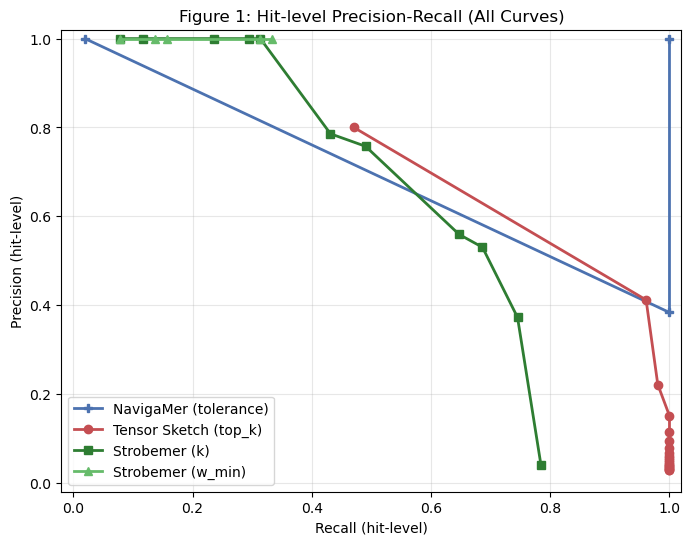

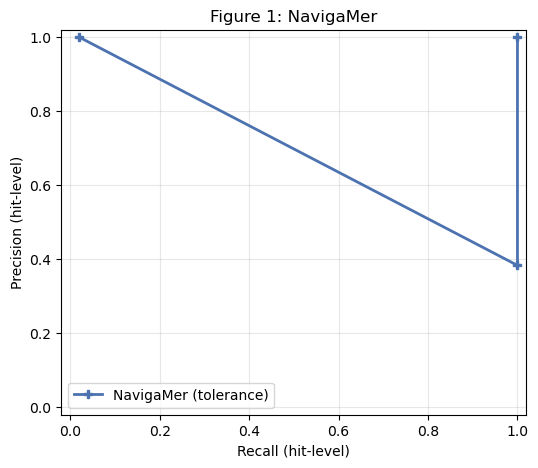

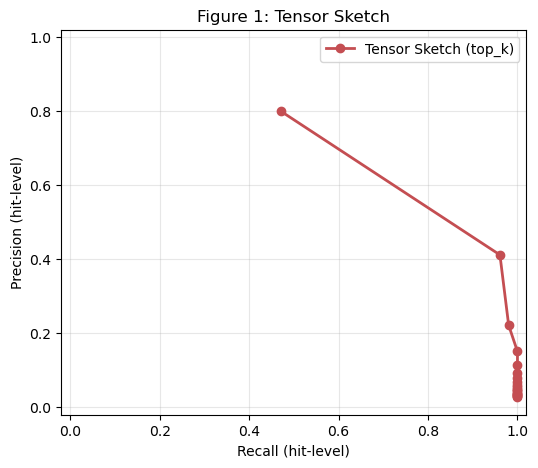

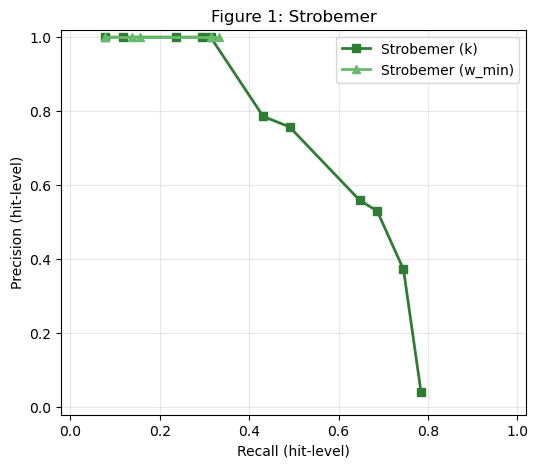

/tmp/ipykernel_3819596/3682964803.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


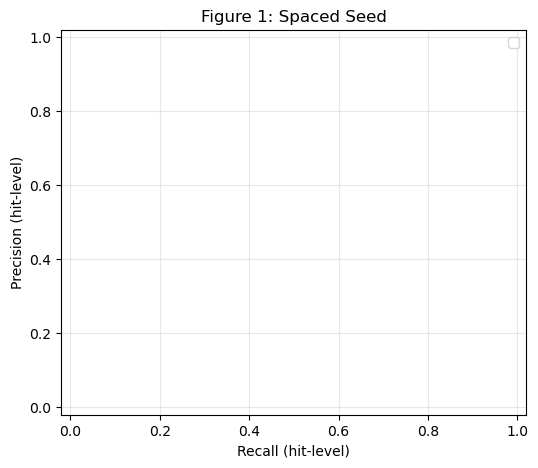

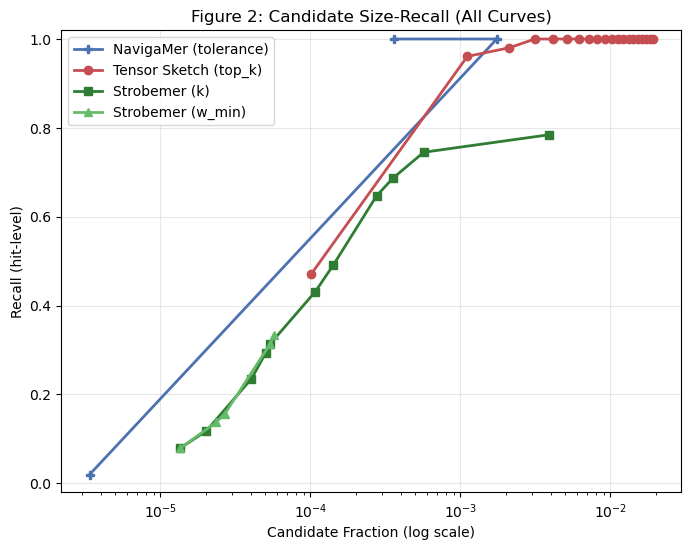

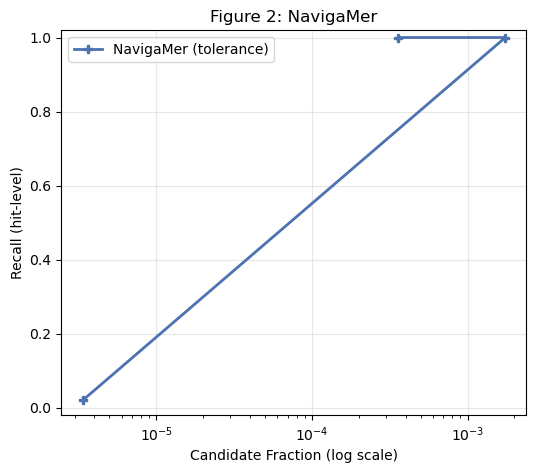

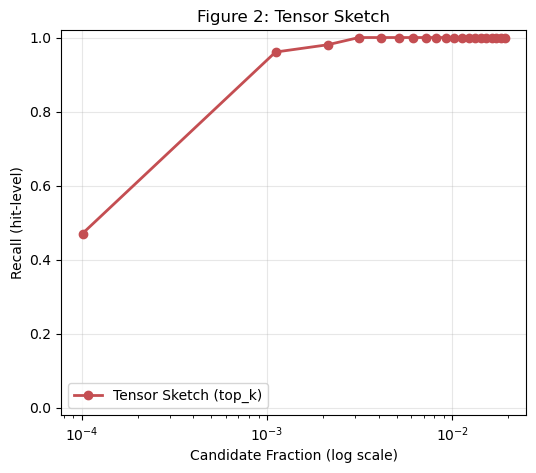

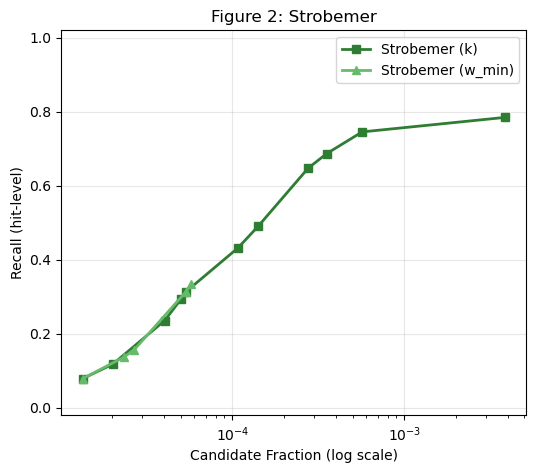

/tmp/ipykernel_3819596/3682964803.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


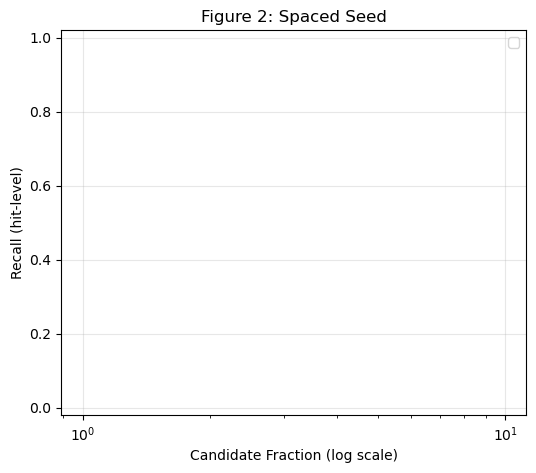

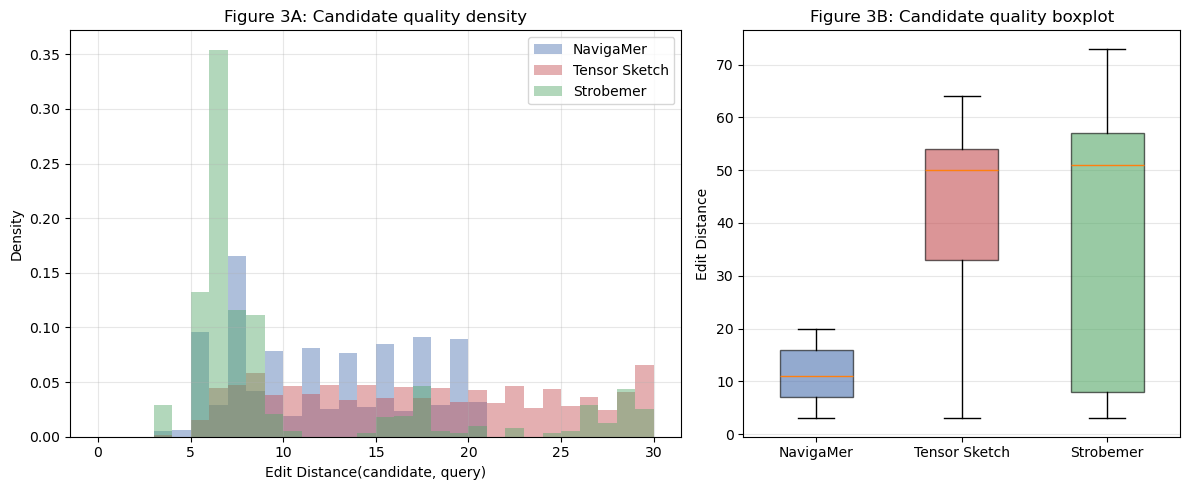

Saved: /home/luting/projects/AnchorMapping/NavigaMer/methods/v4_benchmark_output/pr_plot_data.json


In [10]:
# ── Figure 1/2/3 + plot data ──
CURVE_COLORS = {'navigamer_tolerance': '#4C72B0', 'ts_top_k': '#C44E52', 'strobemer_k': '#2E7D32', 'strobemer_w_min': '#66BB6A', 'spaced_weight': '#E65100'}
CURVE_MARKERS = {'navigamer_tolerance': 'P', 'ts_top_k': 'o', 'strobemer_k': 's', 'strobemer_w_min': '^', 'spaced_weight': 'D'}
curve_labels = {s['curve_id']: s['label'] for s in CURVE_SPECS}
method_to_curves = {
    'navigamer': ['navigamer_tolerance'],
    'tensor_sketch': ['ts_top_k'],
    'strobemer': ['strobemer_k', 'strobemer_w_min'],
    'spaced_seed': ['spaced_weight'],
}
METHOD_LABELS = {'navigamer': 'NavigaMer', 'tensor_sketch': 'Tensor Sketch', 'strobemer': 'Strobemer', 'spaced_seed': 'Spaced Seed'}
METHOD_COLORS = {'navigamer': '#4C72B0', 'tensor_sketch': '#C44E52', 'strobemer': '#55A868', 'spaced_seed': '#DD8452'}

# Figure 1: hit-level PR (main)
fig1, ax1 = plt.subplots(figsize=(8, 6))
for spec in CURVE_SPECS:
    cid = spec['curve_id']
    pts = curve_series.get(cid, [])
    if not pts:
        continue
    x = [p['recall_hit'] for p in pts]
    y = [p['precision_hit'] for p in pts]
    ax1.plot(x, y, marker=CURVE_MARKERS[cid], color=CURVE_COLORS[cid], linewidth=2, markersize=6, label=curve_labels[cid])
ax1.set_xlabel('Recall (hit-level)')
ax1.set_ylabel('Precision (hit-level)')
ax1.set_title('Figure 1: Hit-level Precision-Recall (All Curves)')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.02, 1.02)
fig1.savefig(OUTPUT_DIR / 'fig1_hit_pr_main.png', bbox_inches='tight', dpi=150)
plt.show()

# Figure 1: per-method subplots
for method, cids in method_to_curves.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    for cid in cids:
        pts = curve_series.get(cid, [])
        if not pts:
            continue
        x = [p['recall_hit'] for p in pts]
        y = [p['precision_hit'] for p in pts]
        ax.plot(x, y, marker=CURVE_MARKERS[cid], color=CURVE_COLORS[cid], linewidth=2, markersize=6, label=curve_labels[cid])
    ax.set_xlabel('Recall (hit-level)')
    ax.set_ylabel('Precision (hit-level)')
    ax.set_title(f'Figure 1: {METHOD_LABELS[method]}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    fig.savefig(OUTPUT_DIR / f'fig1_hit_pr_{method}.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 2: candidate size-recall (main)
fig2, ax2 = plt.subplots(figsize=(8, 6))
for spec in CURVE_SPECS:
    cid = spec['curve_id']
    pts = curve_series.get(cid, [])
    if not pts:
        continue
    x = [max(1e-12, p['candidate_fraction']) for p in pts]
    y = [p['recall_hit'] for p in pts]
    ax2.plot(x, y, marker=CURVE_MARKERS[cid], color=CURVE_COLORS[cid], linewidth=2, markersize=6, label=curve_labels[cid])
ax2.set_xscale('log')
ax2.set_xlabel('Candidate Fraction (log scale)')
ax2.set_ylabel('Recall (hit-level)')
ax2.set_title('Figure 2: Candidate Size-Recall (All Curves)')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(-0.02, 1.02)
fig2.savefig(OUTPUT_DIR / 'fig2_candidate_size_recall_main.png', bbox_inches='tight', dpi=150)
plt.show()

# Figure 2: per-method subplots
for method, cids in method_to_curves.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    for cid in cids:
        pts = curve_series.get(cid, [])
        if not pts:
            continue
        x = [max(1e-12, p['candidate_fraction']) for p in pts]
        y = [p['recall_hit'] for p in pts]
        ax.plot(x, y, marker=CURVE_MARKERS[cid], color=CURVE_COLORS[cid], linewidth=2, markersize=6, label=curve_labels[cid])
    ax.set_xscale('log')
    ax.set_xlabel('Candidate Fraction (log scale)')
    ax.set_ylabel('Recall (hit-level)')
    ax.set_title(f'Figure 2: {METHOD_LABELS[method]}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylim(-0.02, 1.02)
    fig.savefig(OUTPUT_DIR / f'fig2_candidate_size_recall_{method}.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 3: candidate quality distribution (like v3 exp4)
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1.4, 1]})
bins = np.arange(0, 31, 1)
for method in ['navigamer', 'tensor_sketch', 'strobemer', 'spaced_seed']:
    d = method_quality_pool.get(method, [])
    if d:
        ax3a.hist(d, bins=bins, alpha=0.45, density=True, label=METHOD_LABELS[method], color=METHOD_COLORS[method])
ax3a.set_xlabel('Edit Distance(candidate, query)')
ax3a.set_ylabel('Density')
ax3a.set_title('Figure 3A: Candidate quality density')
ax3a.grid(True, alpha=0.3)
ax3a.legend()

box_data, box_labels, box_colors = [], [], []
for method in ['navigamer', 'tensor_sketch', 'strobemer', 'spaced_seed']:
    d = method_quality_pool.get(method, [])
    if d:
        box_data.append(d)
        box_labels.append(METHOD_LABELS[method])
        box_colors.append(METHOD_COLORS[method])
if box_data:
    bp = ax3b.boxplot(box_data, tick_labels=box_labels, patch_artist=True, widths=0.5, showfliers=False)
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
ax3b.set_ylabel('Edit Distance')
ax3b.set_title('Figure 3B: Candidate quality boxplot')
ax3b.grid(True, axis='y', alpha=0.3)

fig3.tight_layout()
fig3.savefig(OUTPUT_DIR / 'fig3_candidate_quality.png', bbox_inches='tight', dpi=150)
plt.show()

# Save plot-ready data
fig1_main_series = [{
    'curve_id': s['curve_id'], 'label': curve_labels[s['curve_id']],
    'x': [p['recall_hit'] for p in curve_series.get(s['curve_id'], [])],
    'y': [p['precision_hit'] for p in curve_series.get(s['curve_id'], [])],
    'color': CURVE_COLORS[s['curve_id']], 'marker': CURVE_MARKERS[s['curve_id']]
} for s in CURVE_SPECS]
fig2_main_series = [{
    'curve_id': s['curve_id'], 'label': curve_labels[s['curve_id']],
    'x': [max(1e-12, p['candidate_fraction']) for p in curve_series.get(s['curve_id'], [])],
    'y': [p['recall_hit'] for p in curve_series.get(s['curve_id'], [])],
    'color': CURVE_COLORS[s['curve_id']], 'marker': CURVE_MARKERS[s['curve_id']]
} for s in CURVE_SPECS]

fig1_method_subplots = {
    m: [{
        'curve_id': cid, 'label': curve_labels[cid],
        'x': [p['recall_hit'] for p in curve_series.get(cid, [])],
        'y': [p['precision_hit'] for p in curve_series.get(cid, [])],
        'color': CURVE_COLORS[cid], 'marker': CURVE_MARKERS[cid]
    } for cid in cids] for m, cids in method_to_curves.items()
}
fig2_method_subplots = {
    m: [{
        'curve_id': cid, 'label': curve_labels[cid],
        'x': [max(1e-12, p['candidate_fraction']) for p in curve_series.get(cid, [])],
        'y': [p['recall_hit'] for p in curve_series.get(cid, [])],
        'color': CURVE_COLORS[cid], 'marker': CURVE_MARKERS[cid]
    } for cid in cids] for m, cids in method_to_curves.items()
}

plot_data = {
    'fig1_hit_pr': {
        'main': fig1_main_series,
        'method_subplots': fig1_method_subplots,
    },
    'fig2_candidate_size_recall': {
        'main': fig2_main_series,
        'method_subplots': fig2_method_subplots,
        'xscale': 'log',
    },
    'fig3_candidate_quality': {
        'hist_density': {m: method_quality_pool.get(m, []) for m in ['navigamer', 'tensor_sketch', 'strobemer', 'spaced_seed']},
        'method_labels': METHOD_LABELS,
        'method_colors': METHOD_COLORS,
        'bins': list(bins),
    }
}
with open(OUTPUT_DIR / 'pr_plot_data.json', 'w') as f:
    json.dump(plot_data, f, indent=2, default=json_serial)
print('Saved:', OUTPUT_DIR / 'pr_plot_data.json')

In [11]:
# ── Summary (hit-level) ──
def summarize(curve_series, curve_labels):
    lines = []
    for cid, pts in curve_series.items():
        if len(pts) < 2:
            continue
        p0, p1 = pts[0], pts[-1]
        rg = p1['recall_hit'] - p0['recall_hit']
        pd = p0['precision_hit'] - p1['precision_hit']
        cf0, cf1 = p0['candidate_fraction'], p1['candidate_fraction']
        lines.append(f"{curve_labels[cid]}: R {p0['recall_hit']:.3f}->{p1['recall_hit']:.3f}, P {p0['precision_hit']:.3f}->{p1['precision_hit']:.3f}, CandFrac {cf0:.3e}->{cf1:.3e}, dPrec/dRec={(pd/rg if abs(rg)>1e-9 else float('nan')):.3f}")
    return '\n'.join(lines)

print(summarize(curve_series, {s['curve_id']: s['label'] for s in CURVE_SPECS}))

NavigaMer (tolerance): R 0.020->1.000, P 1.000->1.000, CandFrac 3.367e-06->3.602e-04, dPrec/dRec=0.000
Tensor Sketch (top_k): R 0.471->1.000, P 0.800->0.030, CandFrac 1.010e-04->1.828e-02, dPrec/dRec=1.455
Strobemer (k): R 0.078->0.784, P 1.000->0.041, CandFrac 1.347e-05->3.865e-03, dPrec/dRec=1.359
Strobemer (w_min): R 0.078->0.333, P 1.000->1.000, CandFrac 1.347e-05->5.723e-05, dPrec/dRec=0.000
